<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_AR_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')

In [ ]:
df.head()

,IP NUMBER,NAME,AGE,SEX,DIAGNOSIS,KH,KV,AX,AL,ACD,...,POD 6 WEEK V/A,SPH,CYL.1,AXIS.1,POD 6 WEEK AR,POD 3 MONTH V/A,SPH.1,CYL,AXIS.2,POD 3 MONTH AR
0,2682458,NAGAMMA,54,F,LE MC,46.50,47.25,155,22.65,2.76,...,6\12,0.25,-1.25,100.0,+0.25/-1.25/100,6\9,0.5,-1.0,65.0,+0.50/-1.00/65
1,2682462,GOWRAMMA,63,F,LE MC,46.75,48.00,80,21.90,1.99,...,6\18,0.75,-2.00,90.0,+0.75/-2.00/90,6\12,0.5,-2.0,80.0,+0.50/-2.00/80
2,2682451,SUNDRAMMA,78,F,RE BROWN CATARACT,44.00,44.25,20,22.91,3.08,...,6\24,-1.5,-1.00,140.0,-1.50/-1.00/140,NaN,NaN,NaN,NaN,NaN
3,2683506,KUNNABASAMMA,71,F,RE NS II + PSC,45.25,45.75,120,22.32,3.48,...,6\18,-0.5,-0.75,140.0,-0.5/-0.75/140,6\9,-0.5,-0.5,150.0,-0.5/-0.50/150
4,2689441,SANNAIAH,89,M,LE NS II + PSC + CC,45.50,47.00,80,22.31,3.06,...,6\12,0.25,2.25,85.0,+0.25/+2.25/85,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape, df.columns

((174, 27),
 Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
        'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
        'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
        'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
        'POD 3  MONTH    AR'],
       dtype='object'))

In [ ]:
day1AR = df[['SPH', 'CYL', 'AXIS']]
day1AR

,SPH,CYL,AXIS
0,0.25,-1.50,115.0
1,0.75,-2.25,80.0
2,NO CENTER,NaN,NaN
3,-0.75,-1.00,160.0
4,0.25,2.00,75.0
...,...,...,...
169,-2.75,-3.00,75.0
170,NO CENTER,NaN,NaN
171,NO CENTER,NaN,NaN
172,NO CENTER,NaN,NaN


In [ ]:
day1AR.shape, day1AR.columns

((174, 3), Index(['SPH', 'CYL', 'AXIS'], dtype='object'))

In [ ]:
day1AR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPH     172 non-null    object 
 1   CYL     131 non-null    float64
 2   AXIS    131 non-null    float64
dtypes: float64(2), object(1)
memory usage: 4.2+ KB


In [ ]:
day1AR.isnull().sum()

,0
SPH,2
CYL,43
AXIS,43


In [ ]:
day1ARclean = day1AR.dropna()
day1ARclean

,SPH,CYL,AXIS
0,0.25,-1.50,115.0
1,0.75,-2.25,80.0
3,-0.75,-1.00,160.0
4,0.25,2.00,75.0
5,2,-2.00,90.0
...,...,...,...
165,-2.75,-3.00,60.0
167,1.25,-1.75,15.0
168,-0.75,-1.25,95.0
169,-2.75,-3.00,75.0


In [ ]:
day1ARclean.shape, day1ARclean.columns

((131, 3), Index(['SPH', 'CYL', 'AXIS'], dtype='object'))

In [ ]:
day1ARclean.isnull().sum()

,0
SPH,0
CYL,0
AXIS,0


In [ ]:
day1ARclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 0 to 173
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPH     131 non-null    object 
 1   CYL     131 non-null    float64
 2   AXIS    131 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.2+ KB


In [ ]:
day1ARclean.columns

Index(['SPH', 'CYL', 'AXIS', 'Classification', 'myopic_astigmatism'], dtype='object')

In [145]:
# Create a new column 'Classification' in day1ARclean
day1ARclean.loc[:, 'Classification'] = day1ARclean.apply(
    lambda row: 'Myopic Astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'Hyperopic Astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else


                'Other' if row['CYL'] > 0 else
                'Mixed Astigmatism',
    axis=1
)

# View result
classification_day1AR = day1ARclean[['SPH', 'CYL', 'AXIS','Classification']]
display(classification_day1AR)

,SPH,CYL,AXIS,Classification
0,0.25,-1.50,115.0,Mixed Astigmatism
1,0.75,-2.25,80.0,Mixed Astigmatism
3,-0.75,-1.00,160.0,Myopic Astigmatism
4,0.25,2.00,75.0,Hyperopic Astigmatism
5,2,-2.00,90.0,Mixed Astigmatism
...,...,...,...,...
165,-2.75,-3.00,60.0,Myopic Astigmatism
167,1.25,-1.75,15.0,Mixed Astigmatism
168,-0.75,-1.25,95.0,Myopic Astigmatism
169,-2.75,-3.00,75.0,Myopic Astigmatism


In [146]:
# Separate Myopic Astigmatism
myopicastigmatism = day1ARclean[day1ARclean['Classification'] == 'Myopic Astigmatism']

# Separate Hyperopic Astigmatism
hyperopicastigmatism = day1ARclean[day1ARclean['Classification'] == 'Hyperopic Astigmatism']

# Separate Mixed Astigmatism
mixedastigmatism = day1ARclean[day1ARclean['Classification'] == 'Mixed Astigmatism']


In [122]:
myopic_df

,SPH,CYL,AXIS,Classification,myopic_astigmatism
3,-0.75,-1.00,160.0,Myopic Astigmatism,True
7,-1,-0.50,100.0,Myopic Astigmatism,True
12,-1,-1.00,95.0,Myopic Astigmatism,True
17,-1.75,-1.25,15.0,Myopic Astigmatism,True
32,-0.5,-1.00,100.0,Myopic Astigmatism,True
37,-1.75,-3.75,80.0,Myopic Astigmatism,True
41,-1,-0.75,70.0,Myopic Astigmatism,True
42,-1.5,-1.00,50.0,Myopic Astigmatism,True
50,-0.75,-0.50,30.0,Myopic Astigmatism,True
52,-0.75,-1.25,75.0,Myopic Astigmatism,True


In [123]:
hyperopicastigmatism

,SPH,CYL,AXIS,Classification,myopic_astigmatism
4,0.25,2.00,75.0,Hyperopic Astigmatism,False
9,0.25,3.50,18.0,Hyperopic Astigmatism,False
19,2,3.00,105.0,Hyperopic Astigmatism,False
67,1,0.75,95.0,Hyperopic Astigmatism,False
76,1,0.50,95.0,Hyperopic Astigmatism,False
95,2.25,3.00,175.0,Hyperopic Astigmatism,False
110,1.75,2.25,100.0,Hyperopic Astigmatism,False
112,1.25,1.00,65.0,Hyperopic Astigmatism,False
113,1.25,0.75,115.0,Hyperopic Astigmatism,False
135,0.75,0.75,115.0,Hyperopic Astigmatism,False


In [125]:
mixedastigmatism

,SPH,CYL,AXIS,Classification,myopic_astigmatism
0,0.25,-1.50,115.0,Mixed Astigmatism,False
1,0.75,-2.25,80.0,Mixed Astigmatism,False
5,2,-2.00,90.0,Mixed Astigmatism,False
8,1.5,-3.25,45.0,Mixed Astigmatism,False
11,0.75,-2.00,20.0,Mixed Astigmatism,False
...,...,...,...,...,...
145,1.5,-1.50,80.0,Mixed Astigmatism,False
149,2.5,-1.00,65.0,Mixed Astigmatism,False
155,1.25,-1.00,80.0,Mixed Astigmatism,False
163,1.75,-4.25,95.0,Mixed Astigmatism,False


In [147]:
myopic_df.shape, hyperopic_df.shape, mixed_df.shape

((48, 5), (14, 5), (64, 5))

In [136]:
myopic_df.head()

,SPH,CYL,AXIS,Classification,myopic_astigmatism
3,-0.75,-1.00,160.0,Myopic Astigmatism,True
7,-1,-0.50,100.0,Myopic Astigmatism,True
12,-1,-1.00,95.0,Myopic Astigmatism,True
17,-1.75,-1.25,15.0,Myopic Astigmatism,True
32,-0.5,-1.00,100.0,Myopic Astigmatism,True


In [148]:
# Grouped descriptive statistics for each classification
summary_stats = day1ARclean.groupby('Classification')[['SPH', 'CYL', 'AXIS']].describe()
print(summary_stats)


                        CYL                                                \
                      count      mean       std   min     25%   50%   75%   
Classification                                                              
Hyperopic Astigmatism  14.0  1.928571  1.178447  0.50  0.8125  1.75  3.00   
Mixed Astigmatism      64.0 -2.257812  1.322102 -5.75 -2.8125 -2.00 -1.25   
Myopic Astigmatism     48.0 -1.848958  1.248126 -4.75 -2.6250 -1.25 -1.00   
Other                   5.0  1.950000  1.327592  1.00  1.0000  1.00  3.00   

                             AXIS                                           \
                        max count       mean        std   min    25%   50%   
Classification                                                               
Hyperopic Astigmatism  3.75  14.0  97.000000  42.197339  18.0  76.25  95.0   
Mixed Astigmatism     -0.25  64.0  84.609375  30.928806  10.0  75.00  85.0   
Myopic Astigmatism    -0.50  48.0  93.125000  43.924803   5.0  65.00  

In [149]:
compact_summary = day1ARclean.groupby('Classification')[['SPH', 'CYL', 'AXIS']].agg(['mean', 'std', 'min', 'max', 'count'])
print(compact_summary)


                            SPH                                   CYL  \
                           mean       std   min   max count      mean   
Classification                                                          
Hyperopic Astigmatism  1.214286  0.908598  0.25   3.5    14  1.928571   
Mixed Astigmatism      1.121094  0.759846   0.0   3.0    64 -2.257812   
Myopic Astigmatism        -1.25  0.862949 -3.25 -0.25    48 -1.848958   
Other                     -0.75  0.883883 -2.25   0.0     5  1.950000   

                                                        AXIS                   \
                            std   min   max count       mean        std   min   
Classification                                                                  
Hyperopic Astigmatism  1.178447  0.50  3.75    14  97.000000  42.197339  18.0   
Mixed Astigmatism      1.322102 -5.75 -0.25    64  84.609375  30.928806  10.0   
Myopic Astigmatism     1.248126 -4.75 -0.50    48  93.125000  43.924803   5.0   
Ot

In [150]:
print("Myopic Astigmatism Summary:\n", myopic_df[['SPH', 'CYL', 'AXIS']].describe())
print("\nHyperopic Astigmatism Summary:\n", hyperopic_df[['SPH', 'CYL', 'AXIS']].describe())
print("\nMixed Astigmatism Summary:\n", mixed_df[['SPH', 'CYL', 'AXIS']].describe())


Myopic Astigmatism Summary:
              CYL        AXIS
count  48.000000   48.000000
mean   -1.848958   93.125000
std     1.248126   43.924803
min    -4.750000    5.000000
25%    -2.625000   65.000000
50%    -1.250000   95.000000
75%    -1.000000  116.250000
max    -0.500000  180.000000

Hyperopic Astigmatism Summary:
              CYL        AXIS
count  14.000000   14.000000
mean    1.928571   97.000000
std     1.178447   42.197339
min     0.500000   18.000000
25%     0.812500   76.250000
50%     1.750000   95.000000
75%     3.000000  112.500000
max     3.750000  175.000000

Mixed Astigmatism Summary:
              CYL        AXIS
count  64.000000   64.000000
mean   -2.257812   84.609375
std     1.322102   30.928806
min    -5.750000   10.000000
25%    -2.812500   75.000000
50%    -2.000000   85.000000
75%    -1.250000   95.000000
max    -0.250000  175.000000


In [141]:
day1ARclean = day1ARclean.dropna(subset=['SPH'])


In [151]:
summary_stats = day1ARclean.groupby('Classification')[['SPH', 'CYL', 'AXIS']].agg(['mean', 'std', 'min', 'max', 'count'])
print(summary_stats)


                            SPH                                   CYL  \
                           mean       std   min   max count      mean   
Classification                                                          
Hyperopic Astigmatism  1.214286  0.908598  0.25   3.5    14  1.928571   
Mixed Astigmatism      1.121094  0.759846   0.0   3.0    64 -2.257812   
Myopic Astigmatism        -1.25  0.862949 -3.25 -0.25    48 -1.848958   
Other                     -0.75  0.883883 -2.25   0.0     5  1.950000   

                                                        AXIS                   \
                            std   min   max count       mean        std   min   
Classification                                                                  
Hyperopic Astigmatism  1.178447  0.50  3.75    14  97.000000  42.197339  18.0   
Mixed Astigmatism      1.322102 -5.75 -0.25    64  84.609375  30.928806  10.0   
Myopic Astigmatism     1.248126 -4.75 -0.50    48  93.125000  43.924803   5.0   
Ot

In [152]:
import pandas as pd

# Ensure numeric type
day1ARclean['SPH'] = pd.to_numeric(day1ARclean['SPH'], errors='coerce')
day1ARclean['CYL'] = pd.to_numeric(day1ARclean['CYL'], errors='coerce')
day1ARclean['AXIS'] = pd.to_numeric(day1ARclean['AXIS'], errors='coerce')

# Drop missing values for summary stats
filtered = day1ARclean.dropna(subset=['SPH', 'CYL', 'AXIS'])

# Grouped summary
summary = filtered.groupby('Classification')[['SPH', 'CYL', 'AXIS']].agg(['mean', 'std', 'min', 'max', 'count'])
print(summary)


                            SPH                                   CYL  \
                           mean       std   min   max count      mean   
Classification                                                          
Hyperopic Astigmatism  1.214286  0.908598  0.25  3.50    14  1.928571   
Mixed Astigmatism      1.121094  0.759846  0.00  3.00    64 -2.257812   
Myopic Astigmatism    -1.250000  0.862949 -3.25 -0.25    48 -1.848958   
Other                 -0.750000  0.883883 -2.25  0.00     5  1.950000   

                                                        AXIS                   \
                            std   min   max count       mean        std   min   
Classification                                                                  
Hyperopic Astigmatism  1.178447  0.50  3.75    14  97.000000  42.197339  18.0   
Mixed Astigmatism      1.322102 -5.75 -0.25    64  84.609375  30.928806  10.0   
Myopic Astigmatism     1.248126 -4.75 -0.50    48  93.125000  43.924803   5.0   
Ot

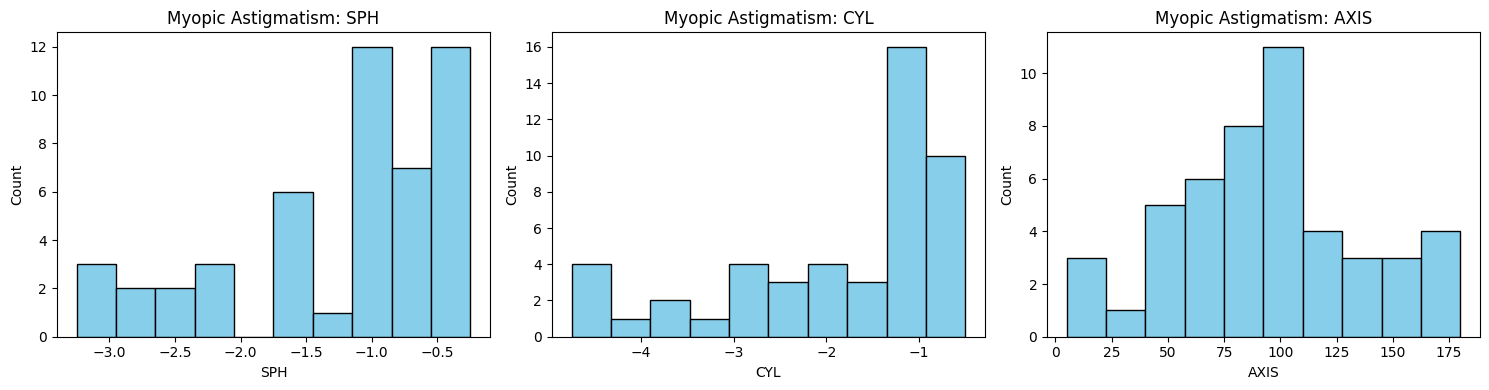

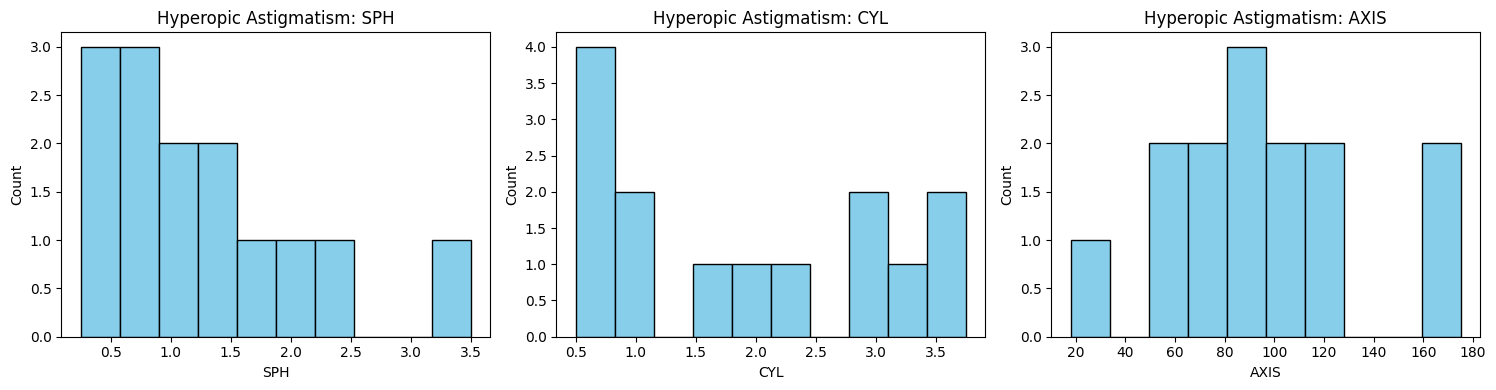

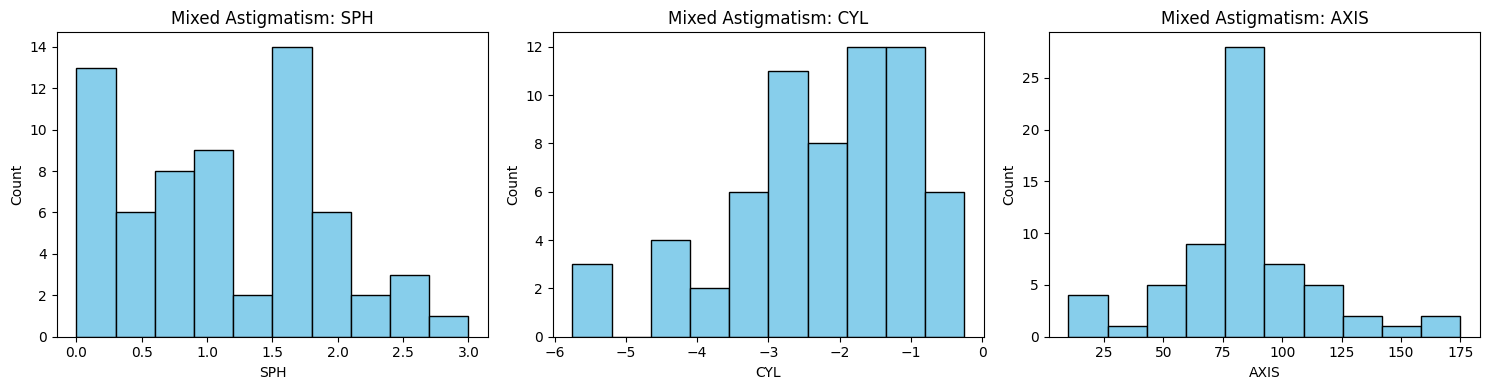

In [153]:
import matplotlib.pyplot as plt

def plot_histograms(group_df, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ['SPH', 'CYL', 'AXIS']):
        ax.hist(group_df[col].dropna(), bins=10, color='skyblue', edgecolor='black')
        ax.set_title(f"{title_prefix}: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histograms(myopic_df, "Myopic Astigmatism")
plot_histograms(hyperopic_df, "Hyperopic Astigmatism")
plot_histograms(mixed_df, "Mixed Astigmatism")


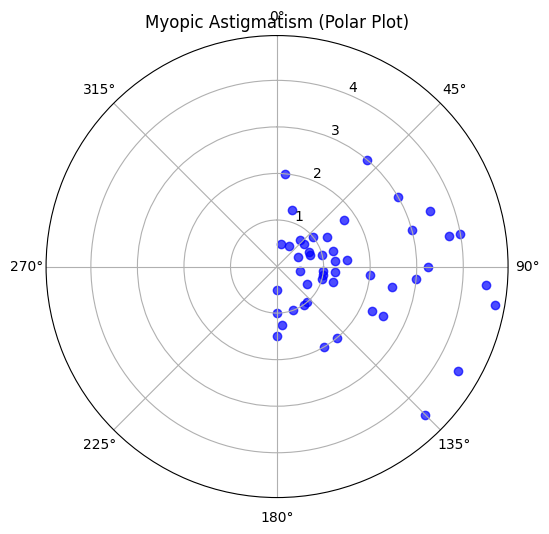

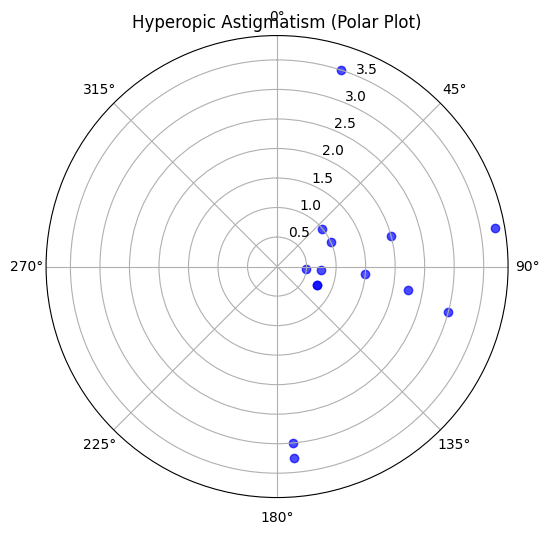

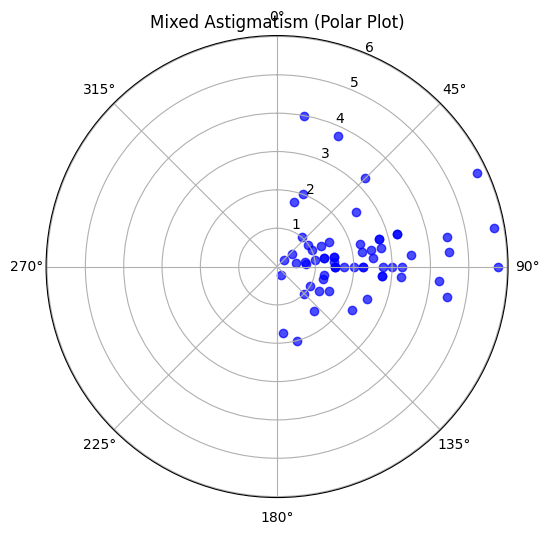

In [154]:
import numpy as np

def plot_polar(group_df, title):
    cyl = group_df['CYL'].abs().dropna()
    axis_deg = group_df['AXIS'].dropna()

    # Convert axis to radians
    axis_rad = np.deg2rad(axis_deg)

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.scatter(axis_rad, cyl, c='blue', alpha=0.7)
    ax.set_theta_zero_location('N')  # 0° at the top
    ax.set_theta_direction(-1)       # Clockwise
    ax.set_title(title)
    plt.show()

plot_polar(myopic_df, "Myopic Astigmatism (Polar Plot)")
plot_polar(hyperopic_df, "Hyperopic Astigmatism (Polar Plot)")
plot_polar(mixed_df, "Mixed Astigmatism (Polar Plot)")


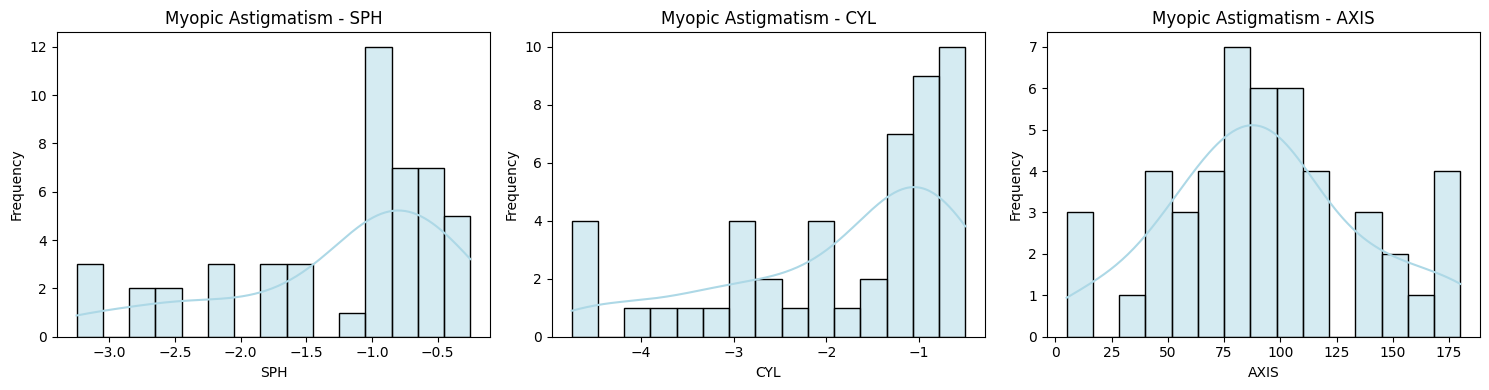

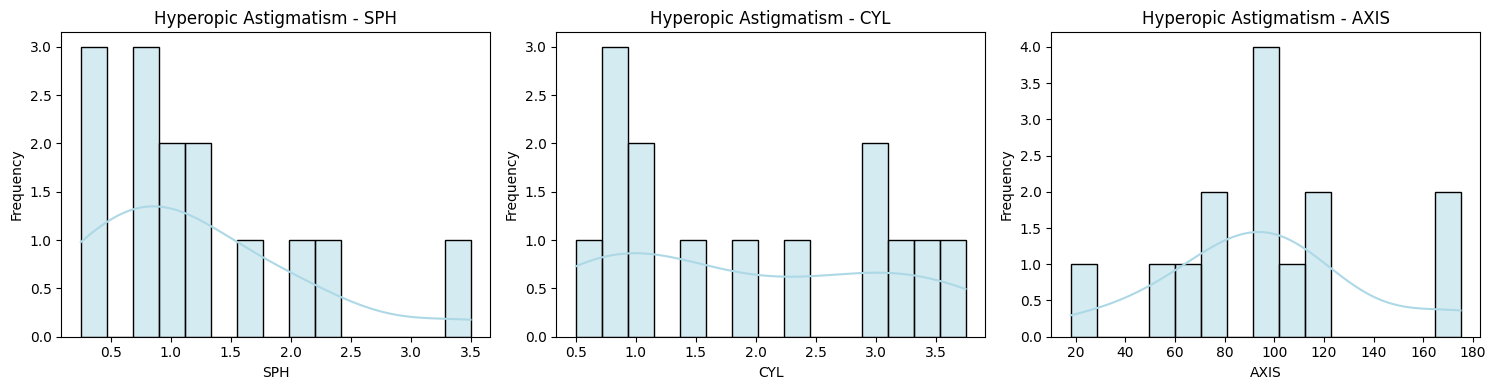

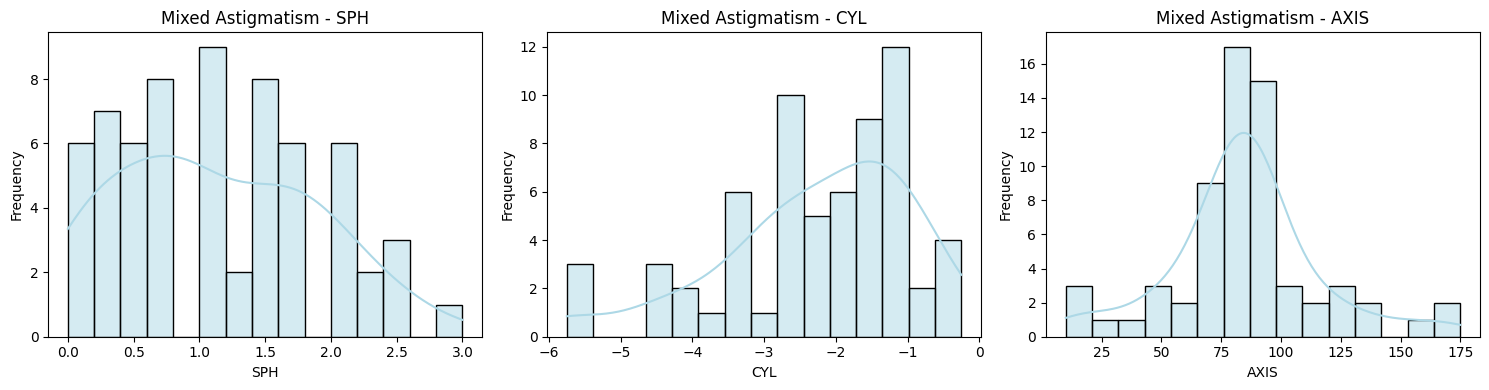

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hist_with_kde(group_df, title_prefix):
    plt.figure(figsize=(15, 4))

    for i, col in enumerate(['SPH', 'CYL', 'AXIS']):
        plt.subplot(1, 3, i+1)
        sns.histplot(group_df[col].dropna(), kde=True, bins=15, color='lightblue', edgecolor='black')
        plt.title(f"{title_prefix} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Plot with bell curves for each group
plot_hist_with_kde(myopic_df, "Myopic Astigmatism")
plot_hist_with_kde(hyperopic_df, "Hyperopic Astigmatism")
plot_hist_with_kde(mixed_df, "Mixed Astigmatism")


/tmp/ipython-input-818689975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='SPH', data=day1ARclean, palette='pastel')


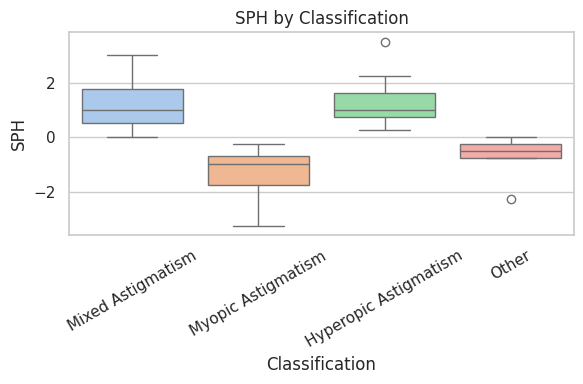

/tmp/ipython-input-818689975.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='CYL', data=day1ARclean, palette='pastel')


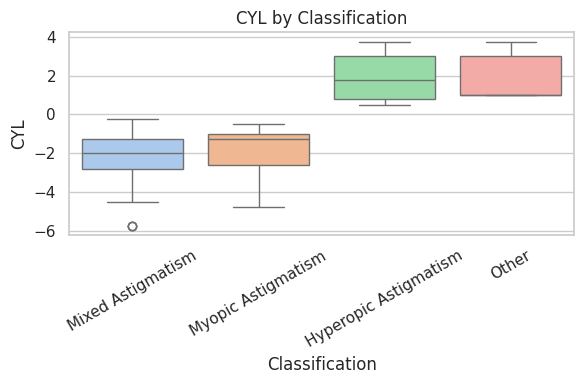

/tmp/ipython-input-818689975.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='AXIS', data=day1ARclean, palette='pastel')


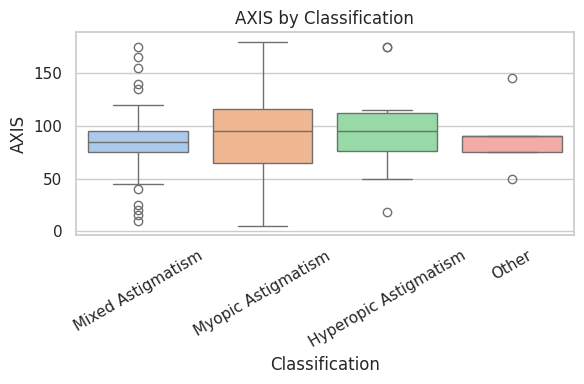

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Boxplot for SPH
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='SPH', data=day1ARclean, palette='pastel')
plt.title('SPH by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for CYL
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='CYL', data=day1ARclean, palette='pastel')
plt.title('CYL by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for AXIS
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='AXIS', data=day1ARclean, palette='pastel')
plt.title('AXIS by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
